## Introduction
In this projecct, I will build a classification model to predict whether a passenger survived the sinking of the Titanic, based on attributes of each passenger in the data set. Then, I will be building a Random Forest Classifier and modify the pipeline to use a Logistic Regression estimator instead. 

## Objectives
- Use scikit-learn to build a model to solve a classification problem
 - Implement a pipeline to combine your preprocessing steps with a machine learning model
 - Interpret the results of your modelling
 - Update your pipeline with a different machine learning model
 - Compare the preformances of your classifiers

In [1]:
# import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Titanic Passenger data set
Here is the details about the dataset being used in this project. 
| Variable   |	Definition   |
 |:------|:--------------------------------|
 |survived | survived? 0 = No, 1 = yes  |
 |pclass | Ticket class (int)  |
 |sex	 |sex |
 |age	 | age in years  |
 |sibsp  |	# of siblings / spouses aboard the Titanic |
 |parch  |	# of parents / children aboard the Titanic |
 |fare   |	Passenger fare   |
 |embarked | Port of Embarkation |
 |class  |Ticket class (obj)   |
 |who    | man, woman, or child  |
 |adult_male | True/False |
 |alive  | yes/no  |
 |alone  | yes/no  |

In [2]:
# Load titanic dataset from seaborn library
titanic_df = sns.load_dataset('titanic')
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

#### Drop Variables
- `deck` has a lot of missing values so we'll drop it. 
- `age` has quite a few missing values as well.
- `embarked` and `embark_town` don't seem relevant so we'll drop them as well.
- If a passanger survived, he/she would  be alive as well. Therefore we will ignote `alive` too.

#### Target variable
`survived` is our target class variable.

In [4]:
# selece relevant features

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

x = titanic_df[features]
y = titanic_df[target]

### How balanced is the target?

In [5]:
y.value_counts()

survived
0    549
1    342
Name: count, dtype: int64

So about 38% of the passengers in the data set survived.  
Because of this slight imbalance, we should stratify the data when performing train/test split and for cross-validation.

### Split data into training and testing sets

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

### Define preprocessing transformers for numerical and catrgorical features

In [7]:
# Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features.

num_features = x_train.select_dtypes(include=['number']).columns.tolist()
cat_features = x_train.select_dtypes(include=['object','category']).columns.tolist()

### Create separate preprocessing pipelines both data types

In [8]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### Combine the transformers into a single column transformer
Using sklearn "column transformer" estimator to separately transform the features, which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

### Model pipeline
Create a model pipeline by combining the preprocessing with a Random Forest classifier.

In [10]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Defining parameter grid
Using corss-validation to optimize the model

In [11]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

### Performing grid search cross-validation and fitting the best model to the training data

In [12]:
# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True)

### Train the pipeline

In [13]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(x_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

### Model predictions from the grid search estimator on the unseen data

In [14]:
y_pred= model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



### Confusion Matrix

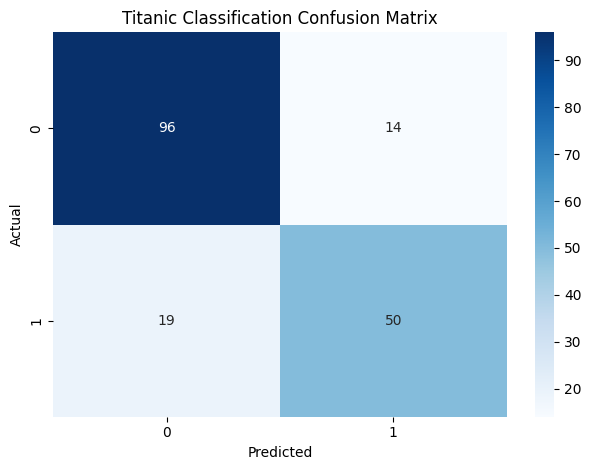

In [15]:
# Enter your code here:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

### Feature importances

In [16]:
model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

In [17]:
feature_imp = model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature named
feat_names = num_features + list(model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features))

### Feature Importances in a Bar Plot

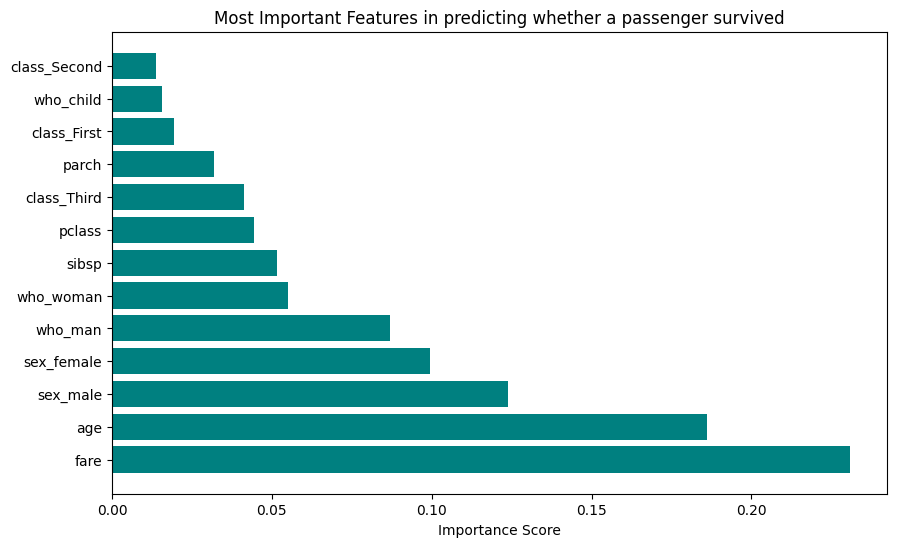

In [18]:
fi_df = pd.DataFrame({'Feature':feat_names,
                      'Importance':feature_imp}).sort_values(by='Importance', ascending=False)

#Bar-plot
plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()

In [19]:
# Test score
ts = model.score(x_test, y_test)
print('Test set accuracy: ', ts*100,'%')

Test set accuracy:  81.56424581005587 %


- From the bar chart, `fare`and `age`are the highest rated features that predict the survival of a passenger.
- Although displayed as different, features `who_man`, `who_woman`,`sex_male`,`sex_female` respresent similar information.
- We need a more detailed modelling approach including correlation analysis, which is required to draw proper conclusions. 

## Train and compare with other model

In [20]:
# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# update the model's estimator to use the new pipeline
model.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

model.param_grid = param_grid

# Fit the updated pipeline with Logistic Regression
model.fit(x_train, y_train)

# Make predictions
y_pred2 = model.predict(x_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

In [21]:
print('Old Model \n',classification_report(y_test, y_pred))
print('New Model \n', classification_report(y_test, y_pred2))

Old Model 
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

New Model 
               precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



The model's accuracy score imporved by 2%, when we switched RandomForese classifier with Logistic Regressor model.

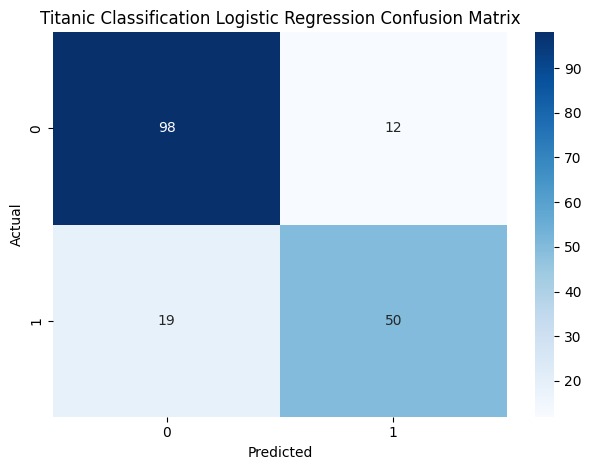

In [22]:
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure()
sns.heatmap(cm2, annot=True, cmap='Blues', fmt='d')
# Set the title and labels
plt.title('Titanic Classification Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

After changing from RandomForest to Logistic Regression, the number of true positives remained the same but the number of true negatives increased by 3. This shows a little imporvement in model predicitons.

### Logistic Regression feature coefficients

In [23]:
lr_coef = model.best_estimator_['classifier'].coef_[0]

# Combine numerical and categorical feature names
lr_feat_names = num_features + list(model.best_estimator_.named_steps['preprocessor']
                                    .named_transformers_['cat']
                                    .named_steps['onehot']
                                    .get_feature_names_out(cat_features))

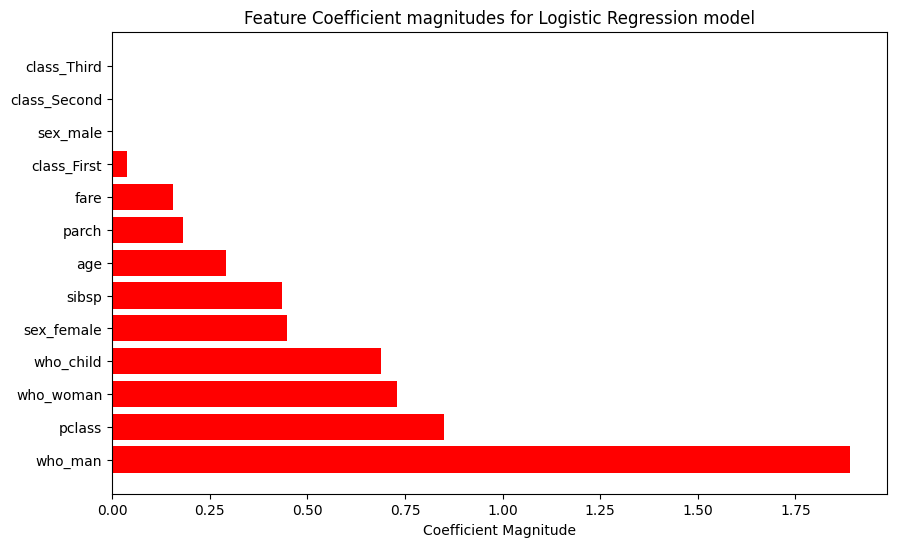

In [24]:
### Bar chart for feature coeffecient magnitudes
lr_imp = pd.DataFrame({'Feature':lr_feat_names,
                       'Coefficients':lr_coef}).sort_values(by='Coefficients', ascending=False, key=abs)

plt.figure(figsize=(10,6))
plt.barh(lr_imp['Feature'], lr_imp['Coefficients'].abs(), color='red')
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

In [25]:
ts2 = model.best_estimator_.score(x_test, y_test)
print('Test set accuracy on Logistic Regression:', ts2*100,'%')

Test set accuracy on Logistic Regression: 82.68156424581005 %


- The accuracy has increased by 2%.
- Although the performances of the two models are virtually identical, the features that are important to the two models are very different. This suggests there must be more work to do to better grasp the actual feature importancdes. There is significant information implied between the variables `who_man`, `who_woman`, and `who_child`, because if a person is neither a man nor a woman, then they muct be a child.

## Compare Model predictions

In [26]:
results = pd.DataFrame({'Actual':y_test,'RF-prediction':y_pred,'LR-prediction':y_pred2})
results.head(10)

,Actual,RF-prediction,LR-prediction
565,0,0,0
160,0,0,0
553,1,0,0
860,0,0,0
241,1,1,1
559,1,0,1
387,1,1,1
536,0,1,0
698,0,0,0
99,0,0,0


**After training both, Random Forest Classifier and Logistic Regression, models the prediction results show that Logistic Regression does a better job at predicting the survival of a passanger in Titanic.**